# Amortized Bayesian Inference of the Diffusion Model for Conflict Tasks

Authored by Stefan T. Radev and Simon Schaefer

Large part of the work below are based on the following paper:
- Schaefer et al., (2026). Amortized Bayesian Workflow for Modeling Congruency Effects Using the Diffusion Model for Conflict Tasks. *Computational Brain & Behavior*. https://link.springer.com/article/10.1007/s42113-026-00266-y

## Model Specification

The Diffusion Model for Conflict Tasks (DMC; Ulrich et al., 2015) extends the standard Drift Diffusion Model by including a time-varying drift-rate component. This allows it to explain reaction time distributions and error rates in conflict tasks such as the Stroop, Simon, and Flanker tasks. In these tasks, performance differs between congruent and incongruent trials because relevant and irrelevant stimulus dimensions can either support the same response or interfere with one another. For example, in a flanker task, participants respond to the direction of a central arrow while ignoring the surrounding arrows.

- **Congruent trial** (e.g., → → → → → ): The central target arrow and the flankers all point in the same direction. Because the irrelevant flankers support the same response as the target, responses are usually faster and more accurate.
- **Incongruent trial** (e.g., → → ← → →): The central target arrow points in the opposite direction from the flankers. Here, the irrelevant flankers activate a competing response, which typically leads to slower responses and more errors.

Compared with a stationary DDM-like process, it has been argued that non-stationary processing better captures this conflict process because it can model how the influence of irrelevant information changes over time. As a result, the DMC is assumed to provide a better account of how the congruency effect develops across the reaction time distribution, for example in delta plots.

Similar to a classic DDM, the DMC comprises a constant drift rate $\mu_c$. This route of evidence accumulation, also referred to as the controlled process is driven by the processing of relevant information such as the target stimulus in a flanker paradigm. Simultaneously, a second *automatic* drift process integrates irrelevant information such as the flanker stimuli in the flanker task. A second time-varying drift rate $\mu_a$ reflects this automatic activation at a given point in time $t$ formulated as the derivative of a reshaped gamma function:

$$\mu_a(t) = A \cdot e^{-t/\tau}\cdot \left[ \frac{t\cdot e}{(a-1)\cdot \tau}\right]^{a-1} \cdot \left[\frac{a - 1}{t}-\frac{1}{\tau}\right], a > 1$$

The sign of the amplitude A is defined by the congruency of relevant and irrelevant information. E.g. in a Flanker task, the amplitude is positive if the flankers (irrelevant dimension) are similar to the target (relevenat information). Adding up both drift rate $\mu_c$ and $\mu_a$ results in the *superimposed* process, resembling the typically observed congruency effect in RTs and error rates.


![DMC_illustration](https://github.com/bayesflow-org/bayesflow_workshops/blob/main/smip_2026/figures/dmc_illustration.png?raw=true)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

import bayesflow as bf

from dmc import DMC, dmc_helpers

In [4]:
param_names = ('A', 'tau', 'mu_c', 'mu_r', 'b', 'sd_r')

simulator = DMC(
    prior_means=np.array([20.49, 118.36, 0.57, 358.01, 61.0, 36.93]),
    prior_sds=np.array([8.4, 37.6, 0.12, 24.27, 13.23, 8.6]), 
    sdr_fixed=None,
    param_names=param_names,
    tmax=1500,
    dt=1
)

Note that the maximum decision time is per default set to $1200 ms$ and the time discretization is set to $dt = 1 ms$. Setting $dt$ to lower values will result in a higher temporal resolution while prolonging the simulation time. $t_{max}$ should be chosen so that $\mu_r + t_{max}$ is higher than the maximum RT in the observed data. In order to account for longer RTs, we set  $t_{max}$ to 1500 ms. 

## Training with Raw Data

In [5]:
num_train = 1000
num_test = 100

train_data = simulator.sample(batch_size=num_train)
test_data = simulator.sample(batch_size=num_test)

**Shape conventions of `simulator.sample()`:** The returned dict contains two kinds of arrays:

- **Parameters** (e.g., `"A"`, `"tau"`, ...): shape `(B, 1)` — one scalar per simulated individual.
- **Trial-level data** (`"rt"`, `"accuracy"`, `"conditions"`): shape `(B, N, 1)` — $N$ trials per individual, with a trailing feature dimension of 1.
- **`"num_obs"`**: shape `(B, 1)` — records how many trials were simulated (can vary between batches when `min_num_obs` / `max_num_obs` are set).

The trailing dimension on trial-level data exists because BayesFlow's summary nets (e.g., `SetTransformer`) expect inputs shaped `(B, N, D)` where $D$ is the number of features per set element.

In [6]:
for key, i in train_data.items():
    print(f'{key}: {i.shape}')

A: (1000, 1)
tau: (1000, 1)
mu_c: (1000, 1)
mu_r: (1000, 1)
b: (1000, 1)
sd_r: (1000, 1)
rt: (1000, 200, 1)
accuracy: (1000, 200, 1)
conditions: (1000, 200, 1)
num_obs: (1000, 1)


In conflict tasks, **Conditional Accuracy Functions (CAFs)**, **Cumulative Distribution Functions (CDFs)**, and **delta functions** are commonly used to examine how cognitive control and interference effects unfold across the full reaction time (RT) distribution, rather than being summarized by single mean values. Together, these distributional analyses provide complementary insights into both the speed and accuracy of responses under congruent and incongruent conditions.

- **Conditional Accuracy Functions (CAFs)** characterize how response accuracy varies as a function of response speed. By dividing RTs into quantile-based bins and computing accuracy within each bin, CAFs reveal whether fast responses are more error-prone and whether accuracy improves or deteriorates for slower responses. In conflict tasks, CAFs are particularly informative about early, impulsive response tendencies versus later, more controlled responding, and whether incongruent trials show disproportionate accuracy costs at specific portions of the RT distribution.

- **Cumulative Distribution Functions (CDFs)** describe the overall shape of the RT distribution for each condition. CDFs plot the cumulative probability of responding as a function of RT, allowing direct comparison of how quickly responses are generated under congruent and incongruent conditions. Differences between CDFs indicate global shifts or shape differences in RT distributions, such as whether incongruent trials produce uniformly slower responses or selectively affect only slower portions of the distribution.

- **$\Delta$ - functions** focus explicitly on the difference between congruent and incongruent RT distributions across response speed. Rather than collapsing the congruency effect into a single mean RT difference, delta functions show how this effect changes across quantiles of the RT distribution. This makes it possible to assess whether interference is constant, increases, or decreases as responses become slower, thereby providing insight into the temporal dynamics of conflict processing and control.

**`format_sim_data` and `only_convergents`:** `format_sim_data` converts the dict of arrays returned by the simulator into a tidy `pandas` DataFrame. The simulated diffusion process sometimes fails to reach a decision boundary within $t_{max}$ — these are "non-convergent" trials. `only_convergents=True` excludes them (they'd have an RT of $-1$ or similar sentinel), keeping only trials where a decision was actually made.

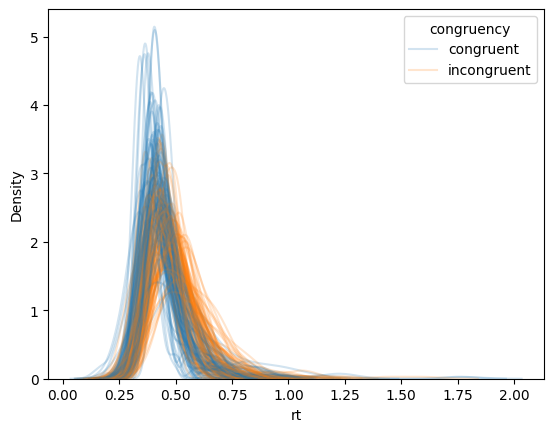

In [7]:
df_complete = dmc_helpers.format_sim_data(test_data, only_convergents=True)

for id in np.arange(0, num_test):

    # select data from individual id
    df_id = df_complete[df_complete['id'] == id]

    # plot rt distribution excluding values of -1
    sns.kdeplot(df_id, x = 'rt', hue='congruency', alpha=0.2)

In [ ]:
workflow = bf.BasicWorkflow(
    inference_network=bf.networks.CouplingFlow(),
    summary_network=bf.networks.SetTransformer(embed_dims=(16, 16), summary_dim=32),
    inference_variables=param_names,
    summary_variables=["rt", "conditions", "accuracy"],
    standardize="all"
)

In [ ]:
history = workflow.fit_offline(
    train_data, batch_size=16, epochs=15, validation_data=test_data
)

In [ ]:
samples = workflow.sample(conditions=test_data, num_samples=1000)

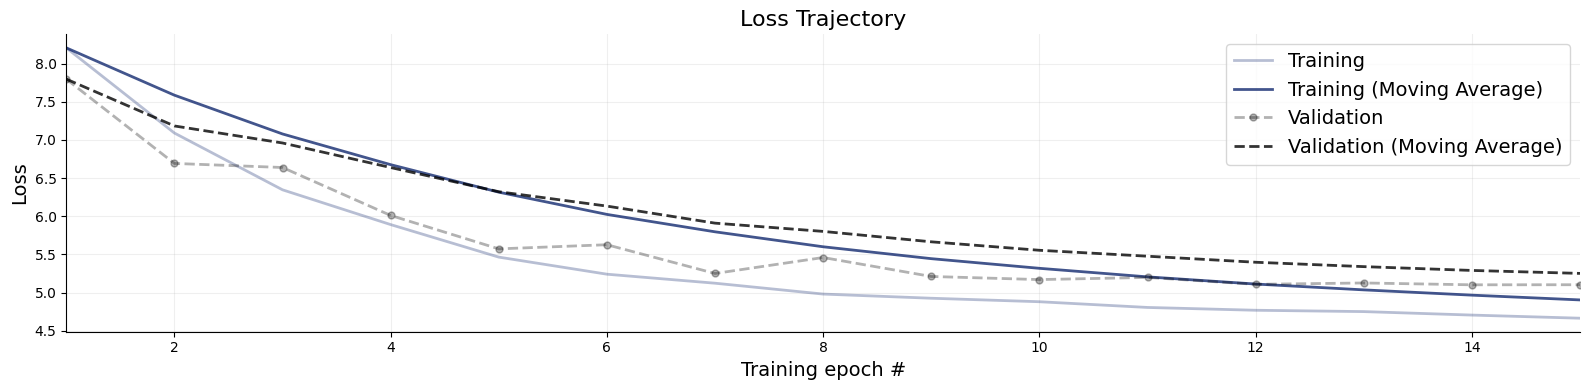

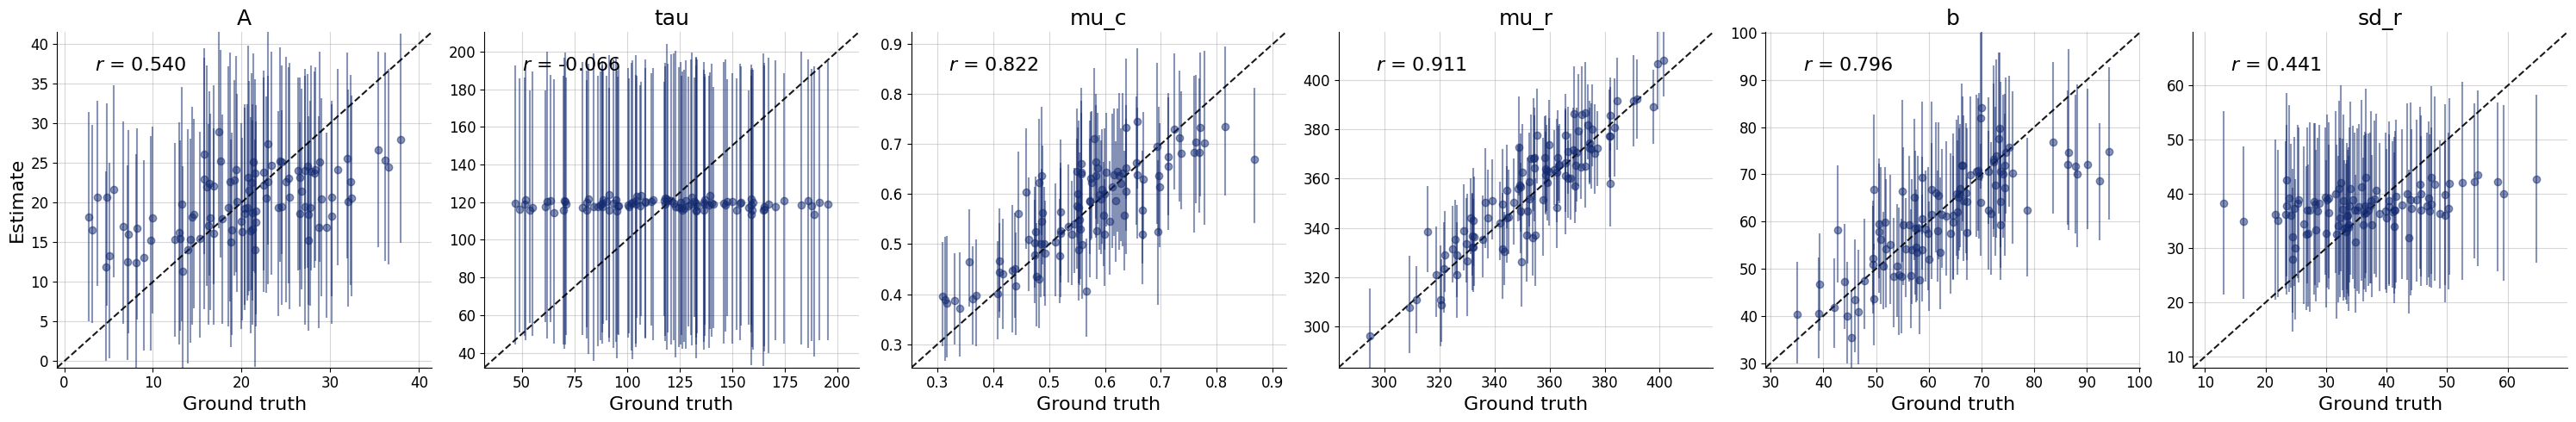

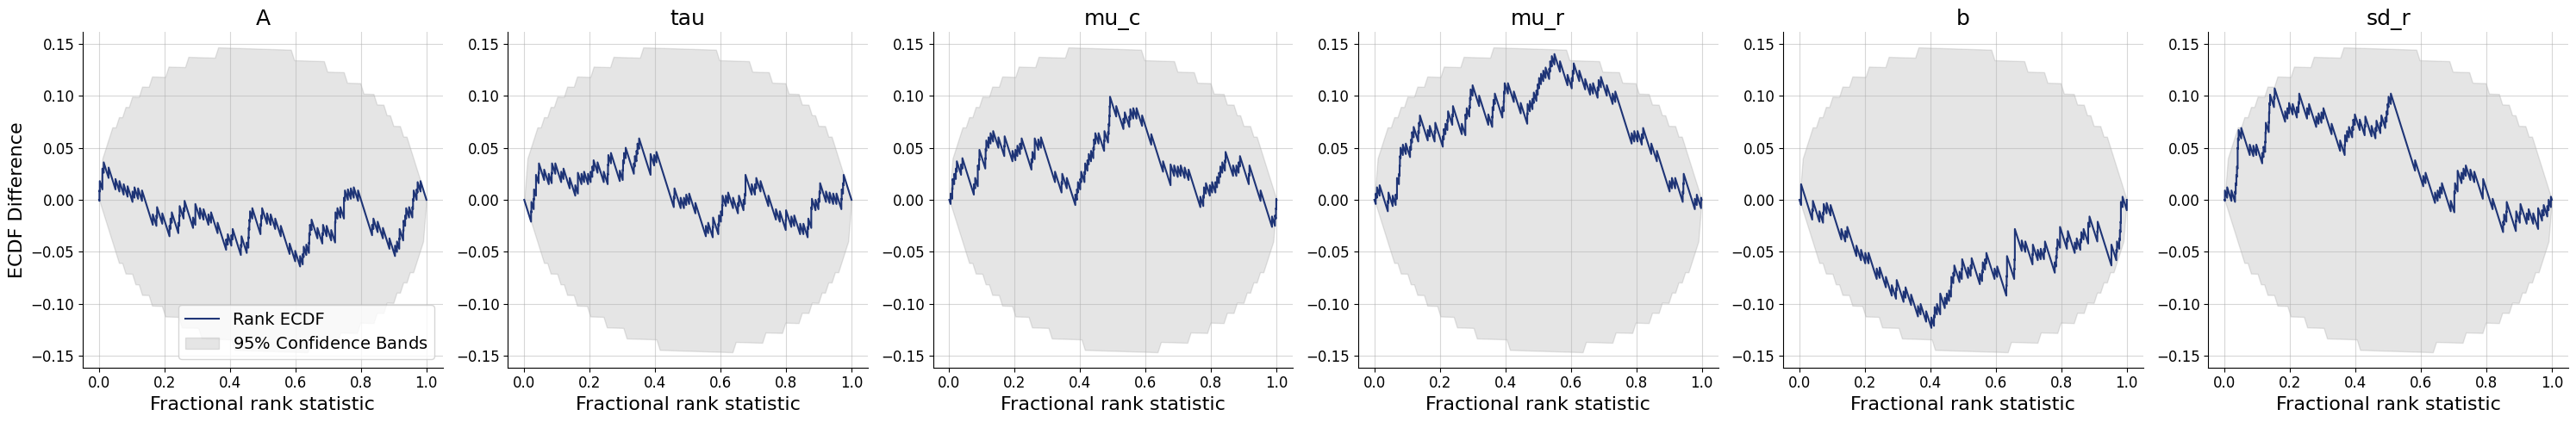

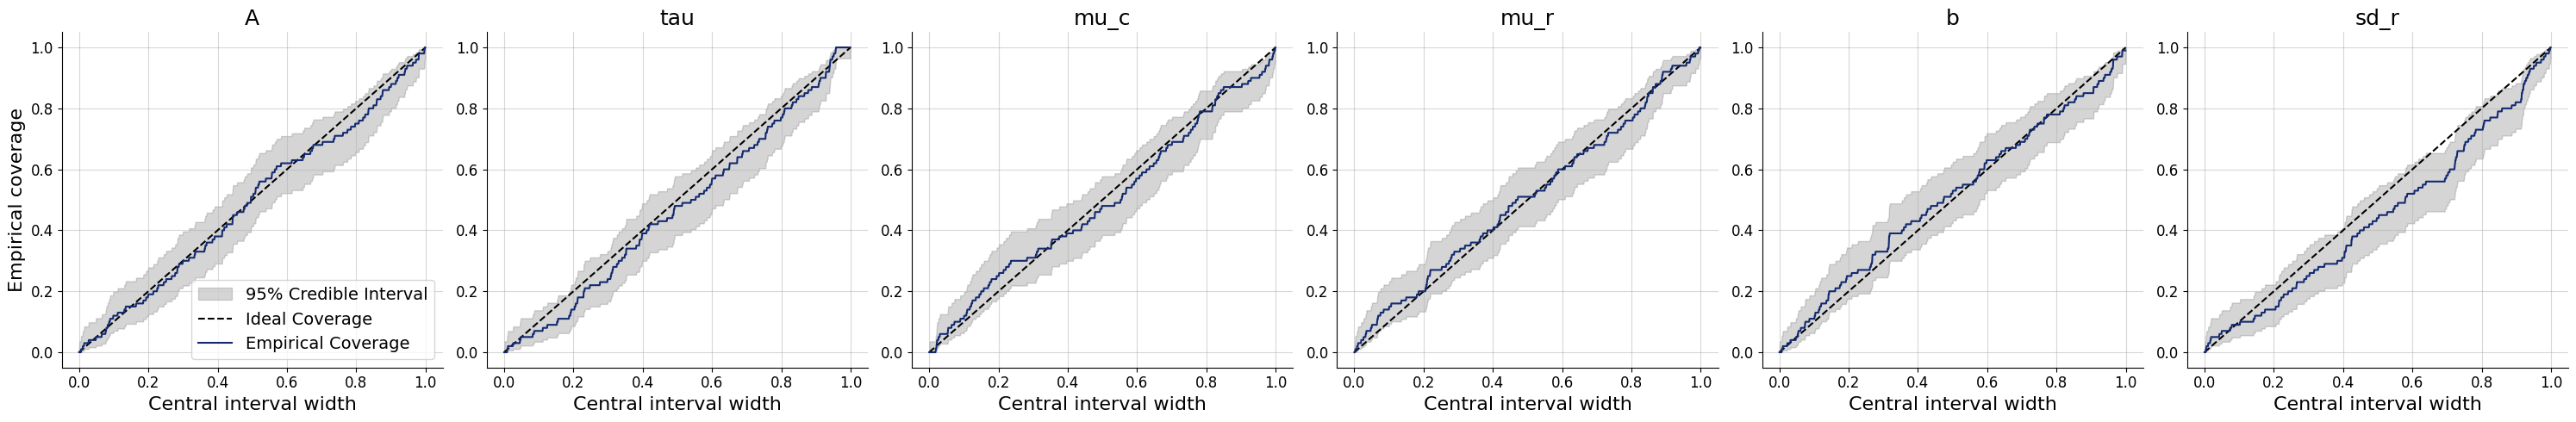

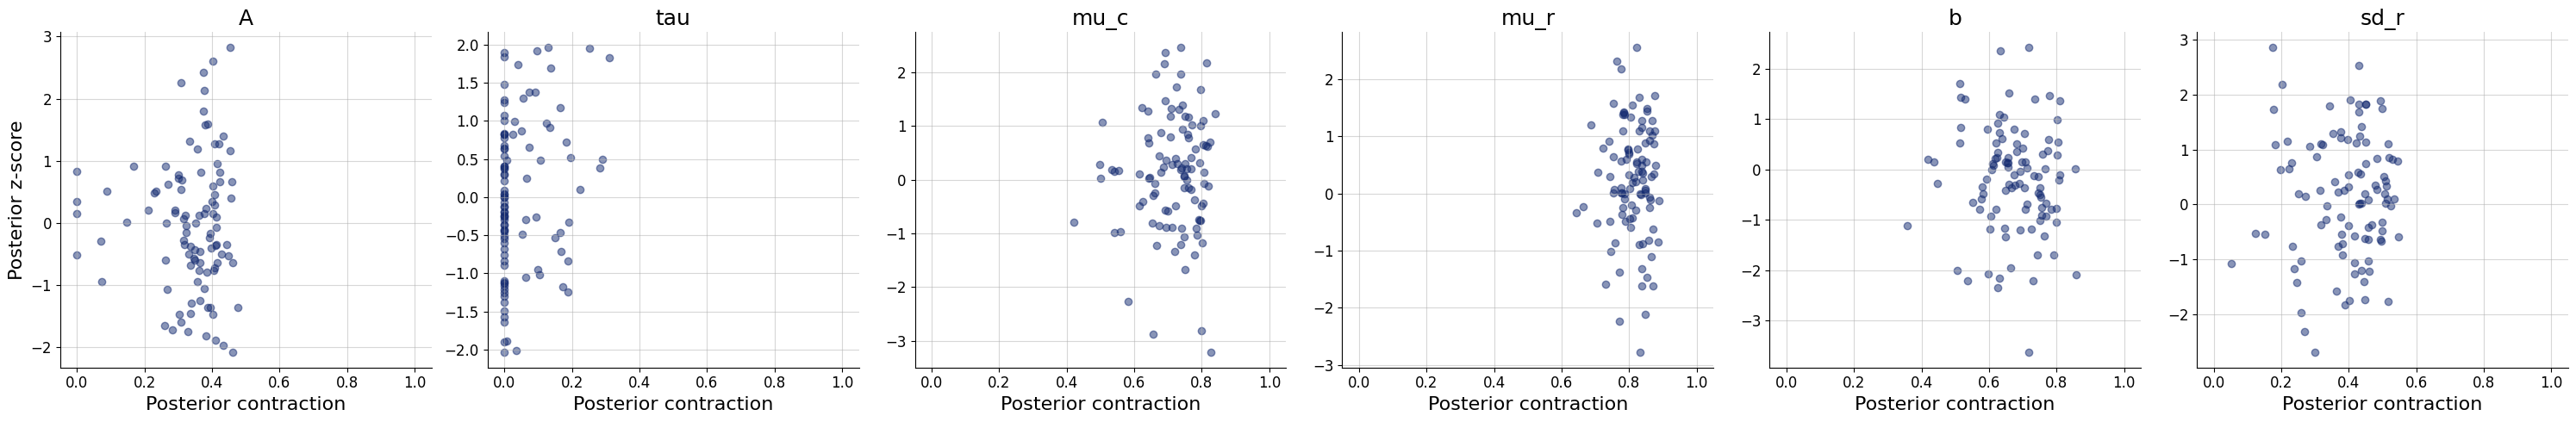

In [30]:
figs = workflow.plot_default_diagnostics(
    test_data=test_data, 
    samples=samples
)

In [31]:
metrics = workflow.compute_default_diagnostics(test_data=test_data, samples=samples)
metrics

,A,tau,mu_c,mu_r,b,sd_r
NRMSE,0.813804,0.995996,0.562522,0.435336,0.551822,0.869841
Log Gamma,2.433806,4.045408,2.684217,0.679866,1.339658,0.999158
Calibration Error,0.013421,0.033684,0.026579,0.020526,0.019737,0.063684
Posterior Contraction,0.364244,0.000000,0.736794,0.819984,0.675206,0.417246


## Training with Informative Summary Statistics

**Key details in `summary_stats`:**

- **`[..., 0]`** strips the trailing dimension: `(B, N, 1)` → `(B, N)`, since each variable is stored as a single-column "feature".
- **Masking with `np.where`:** `np.where(mask, rt, np.nan)` keeps RTs where the mask is `True` and fills the rest with `NaN`. `np.nanquantile` then computes quantiles while ignoring `NaN`s — this avoids explicitly indexing ragged groups per batch.
- **`stats[np.isnan(stats)] = -1.`:** If a group is empty (e.g., no errors for a given condition in a batch), `nanquantile` returns `NaN`. Replacing with $-1$ provides a sentinel value the network can learn to ignore, since RTs are always positive.
- **`**kwargs`:** Absorbs extra dict keys (e.g., `"A"`, `"tau"`, `"num_obs"`, ...) that are present in the data dict but not needed here. This makes the function compatible with `summary_stats(**train_data)`.

In [32]:
def summary_stats(conditions, rt, accuracy, num_quantiles=5, **kwargs):
    """Computes hand-crafted summary statistics to be used on batched conditions, 
    rts, and accuracies.
    """

    quantiles = np.linspace(0.05, 0.95, num_quantiles)
    rt        = rt[..., 0]
    conditions = conditions[..., 0]
    accuracy   = accuracy[..., 0]

    quantile_parts = []
    for cond_val in (0, 1):
        for acc_val in (0, 1):
            mask = (conditions == cond_val) & (accuracy == acc_val)
            q = np.nanquantile(np.where(mask, rt, np.nan), quantiles, axis=1).T
            quantile_parts.append(q)

        
    acc_c0 = np.nanmean(np.where(conditions == 0, accuracy, np.nan), axis=1, keepdims=True)
    acc_c1 = np.nanmean(np.where(conditions == 1, accuracy, np.nan), axis=1, keepdims=True)

    stats = np.concatenate([*quantile_parts, acc_c0, acc_c1], axis=1)

    stats[np.isnan(stats)] = -1.

    return {"summary_stats": stats}

**The `|=` (merge-update) pattern:** `train_data |= summary_stats(**train_data)` unpacks the entire data dict as keyword arguments to `summary_stats`. The function ignores unneeded keys via `**kwargs` and returns `{"summary_stats": ...}`. The `|=` operator merges this back into the original dict, adding the new `"summary_stats"` key alongside the existing `"rt"`, `"conditions"`, etc.

In [33]:
train_data |= summary_stats(**train_data)
test_data |= summary_stats(**test_data)

c:\Users\radevs\AppData\Local\anaconda3\envs\bf\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


**Why no `summary_network` anymore?** 

In the first workflow above, raw trial-level data (`rt`, `conditions`, `accuracy`) was passed as `summary_variables` and a `SetTransformer` learned to compress them into a fixed-size representation. Here, we instead pre-compute hand-crafted summary statistics and pass them via `inference_conditions`. This means the inference network receives a fixed `(B, 22)` vector directly. No learnable summary network is needed. This can be more interpretable and sometimes more data-efficient, but it requires domain knowledge to design good summaries.

In [37]:
workflow = bf.BasicWorkflow(
    inference_network=bf.networks.CouplingFlow(),
    inference_variables=param_names,
    inference_conditions="summary_stats",
    standardize="all"
)

In [ ]:
history = workflow.fit_offline(
    train_data, epochs=50, batch_size=32, validation_data=test_data
)

In [ ]:
samples = workflow.sample(conditions=test_data, num_samples=1000)

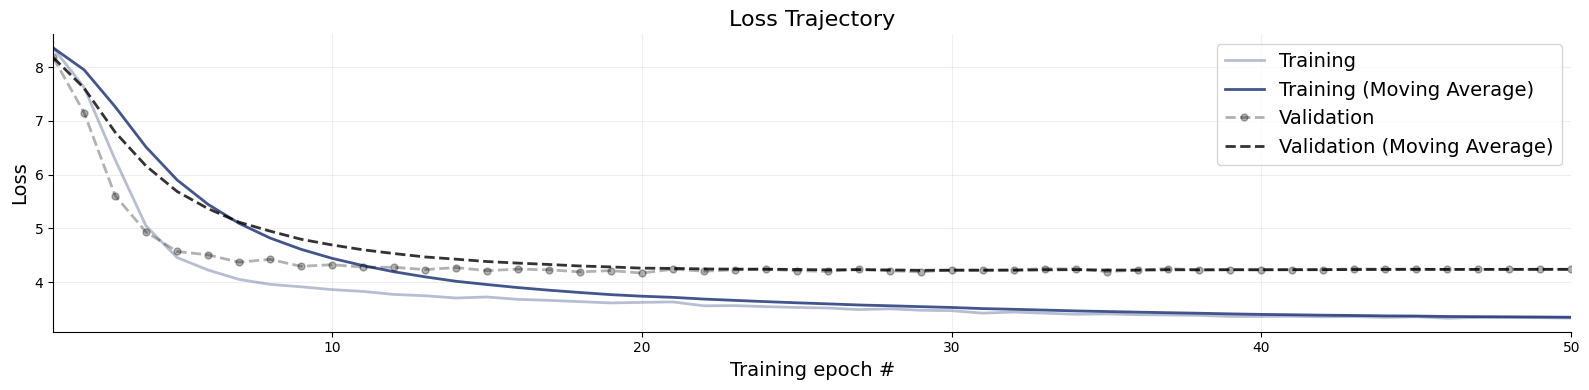

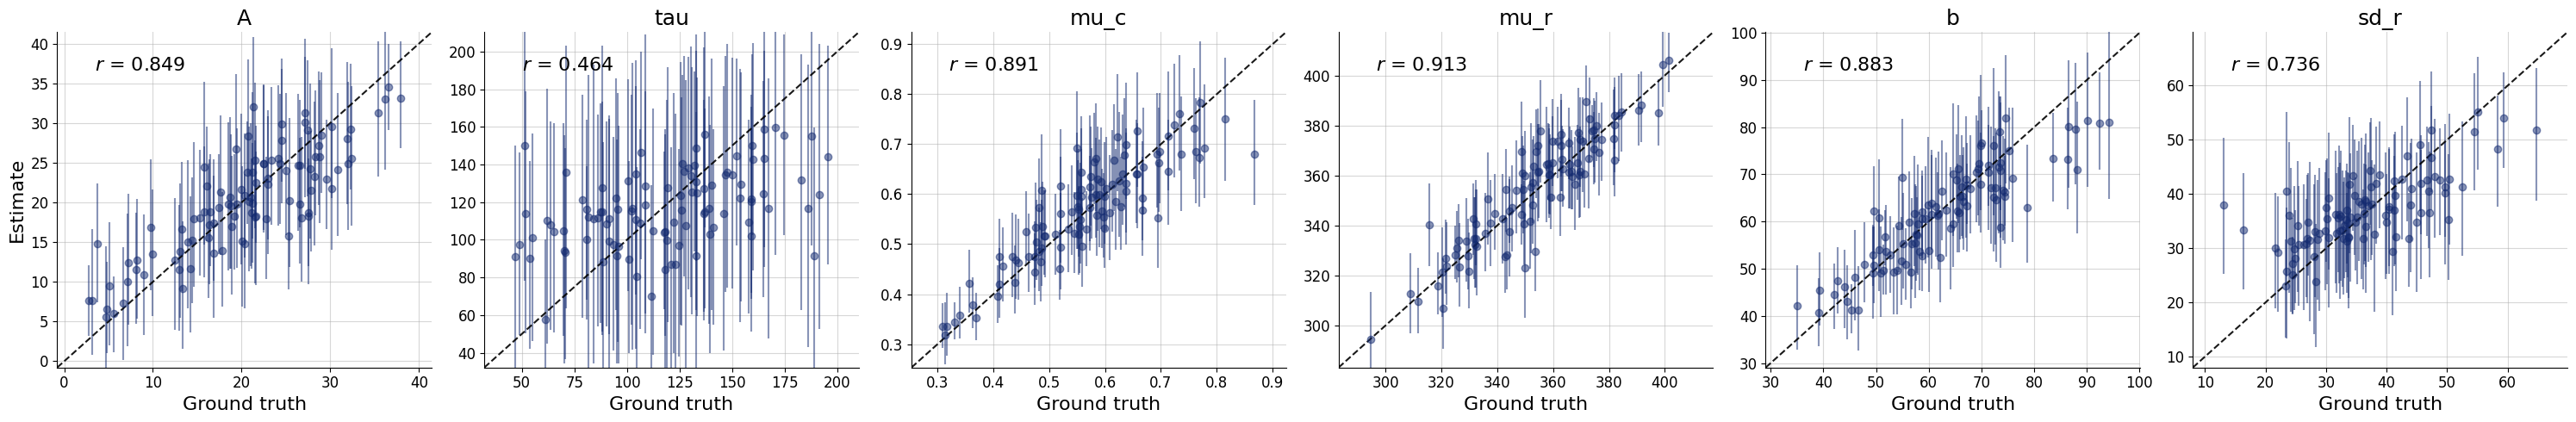

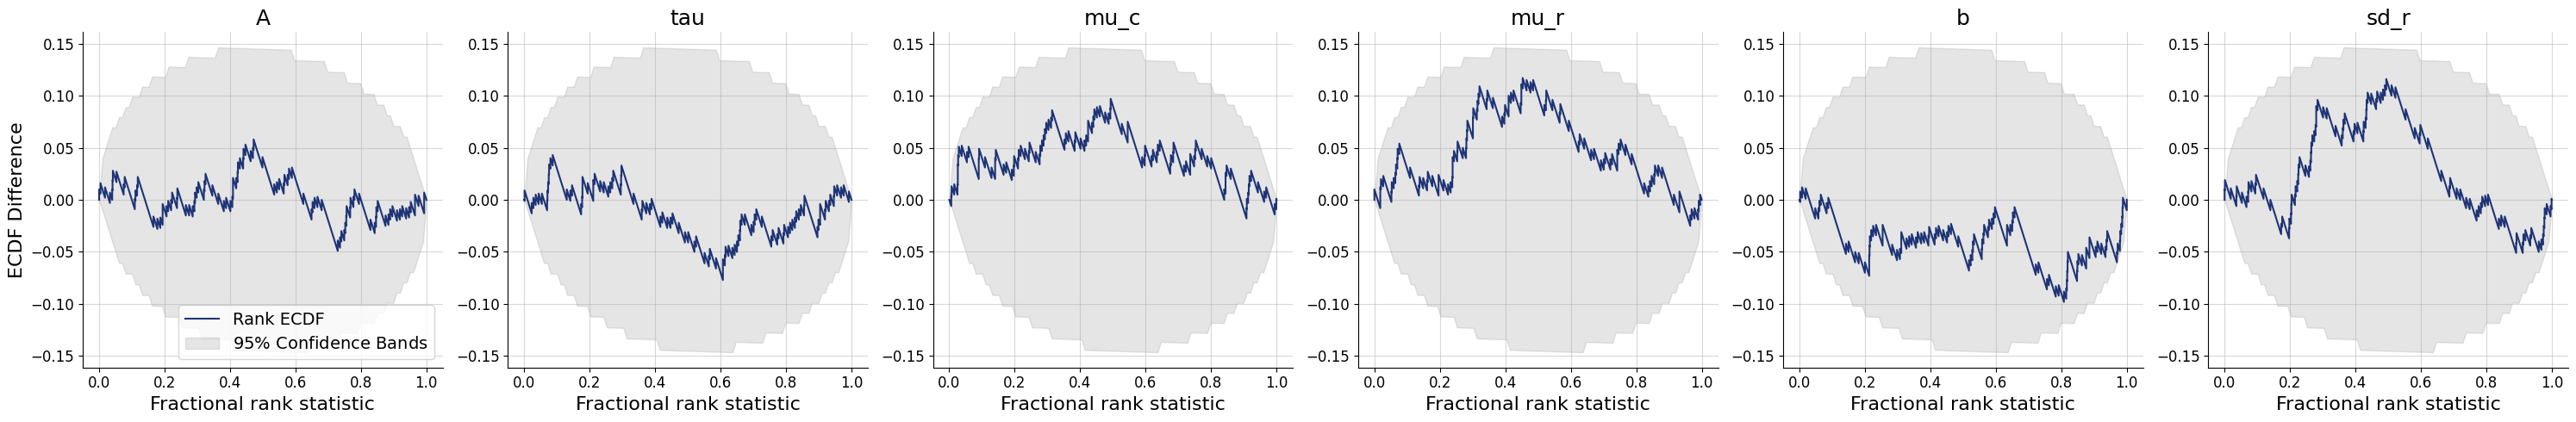

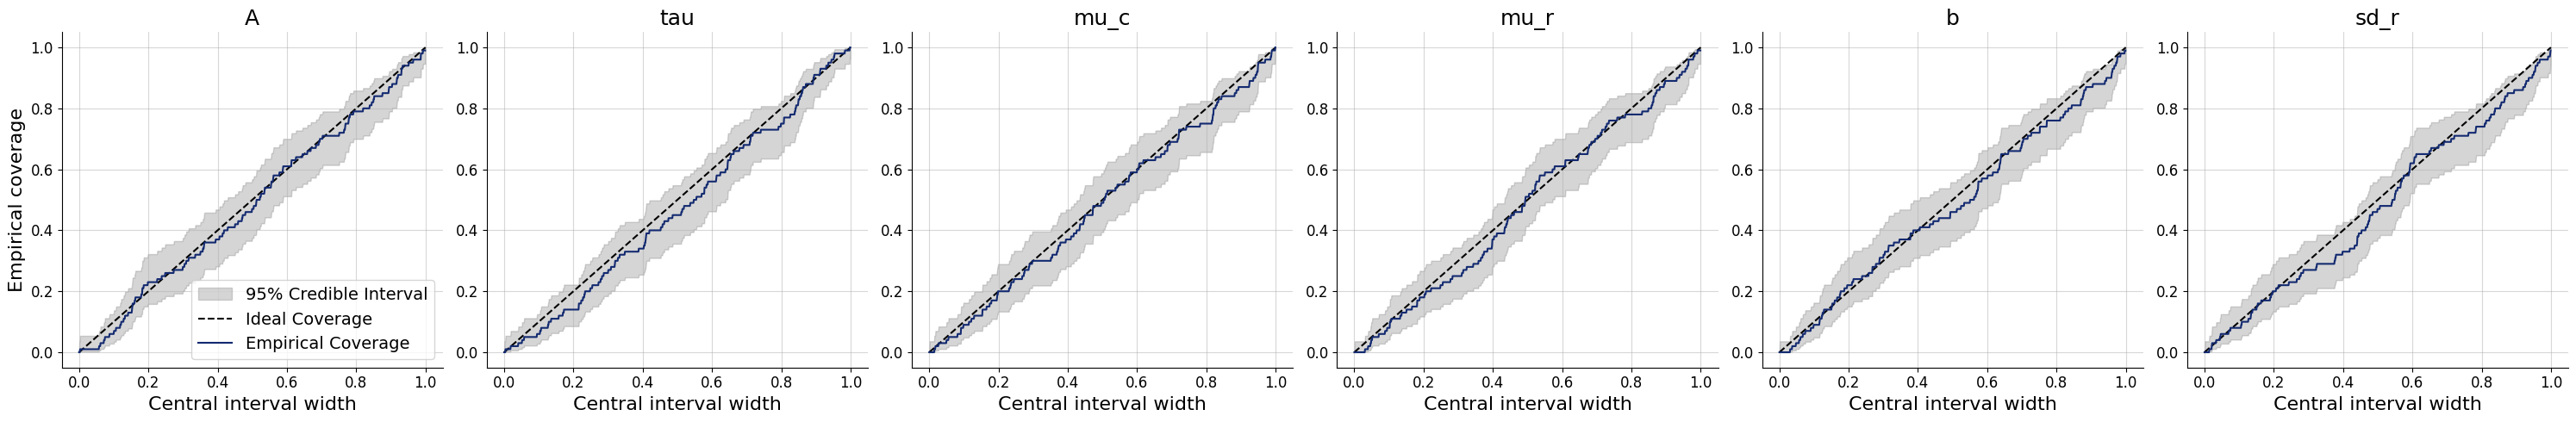

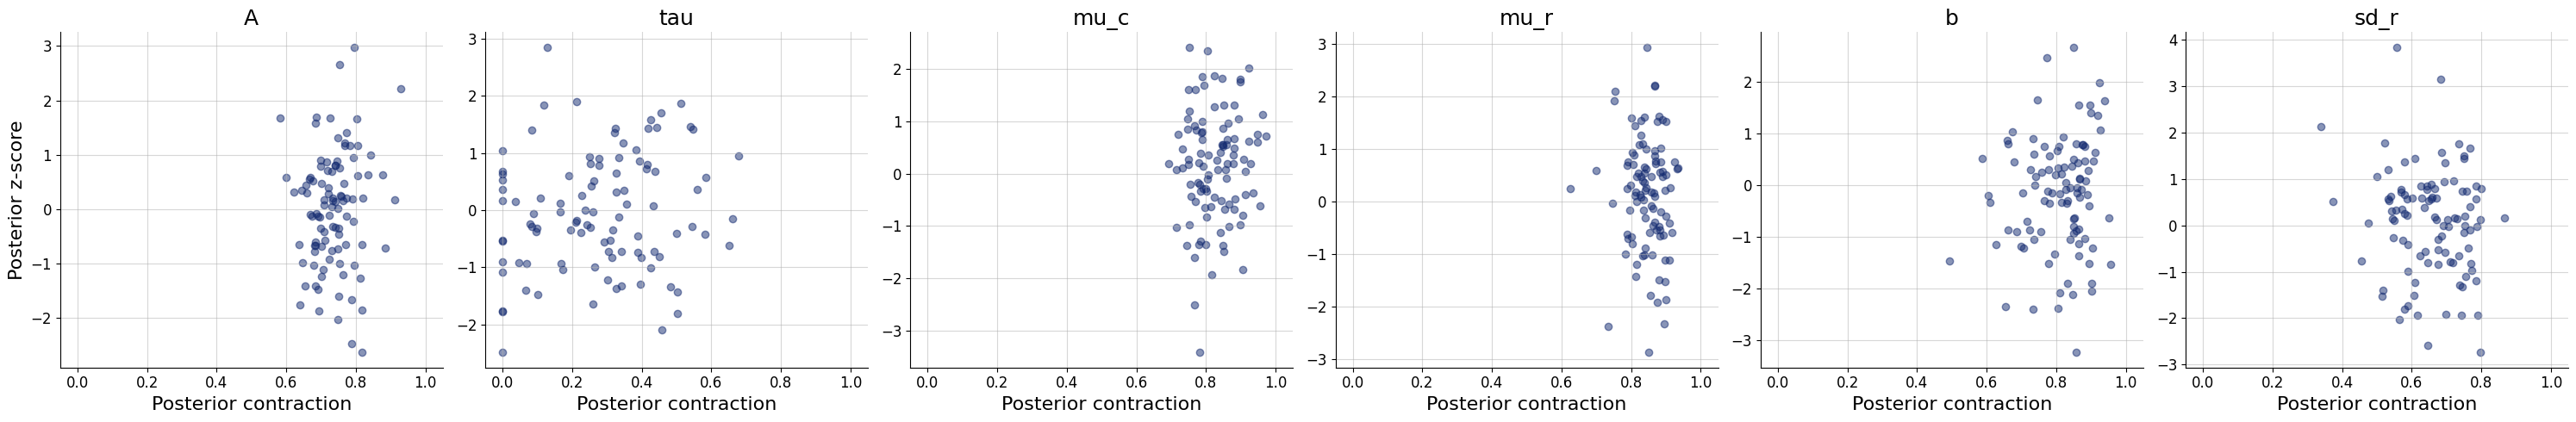

In [40]:
figs = workflow.plot_default_diagnostics(test_data, samples=samples)

## Flow Matching vs. Diffusion Model

### Separate Workflows

In [ ]:
workflows = {}
estimators = {
    "fm": bf.networks.FlowMatching(subnet_kwargs={"widths": (128,)*3}),
    "cf": bf.networks.CouplingFlow()
}
histories = {}

for name, estimator in estimators.items():

    ### Your code here

    ### Your code here

    workflows[name] = workflow
    histories[name] = history

In [ ]:
figs = workflows["fm"].plot_default_diagnostics(
    test_data=test_data, 
    num_samples=300
)

In [ ]:
figs = workflows["cf"].plot_default_diagnostics(
    test_data=test_data, 
    num_samples=300
)

### Ensemble

**`EnsembleWorkflow`** trains multiple inference networks jointly on the same data. Each member learns a different posterior approximation, and their samples can be merged for better coverage.

In [ ]:
workflow = bf.EnsembleWorkflow(
    inference_networks={
        "fm": bf.networks.FlowMatching(subnet_kwargs={"widths": (64,)*3}),
        "dm": bf.networks.DiffusionModel(subnet_kwargs={"widths": (64,)*3}),
    },
    # The rest goes like before
    inference_variables=param_names,
    inference_conditions="summary_stats",
    standardize="all"
)

history = workflow.fit_offline(train_data, batch_size=32, epochs=100, validation_data=test_data)

In [ ]:
# Obtain posterior draws from all ensemble members
marginal_draws = workflow.sample(
    conditions=test_data,
    batch_size=25,
    num_samples=300,
    merge_members=False
)

**Why `merge_members=False`?** By default, `EnsembleWorkflow.sample()` pools draws from all members into a single sample. Setting `merge_members=False` returns a dict keyed by member name, so we can inspect each member's recovery performance individually and diagnose which estimator contributes most (or poorly).

In [ ]:
for member, samples in marginal_draws.items():
    f = bf.diagnostics.recovery(samples, test_data, variable_names=param_names)
    f.suptitle(f"Recovery - Ensemble Member {member.upper()}")

## Adding Consistency Models to the Mix

In [ ]:
workflow = bf.EnsembleWorkflow(
    inference_networks={
        "fm": bf.networks.FlowMatching(subnet_kwargs={"widths": (128,)*3}),
        "dm": bf.networks.DiffusionModel(subnet_kwargs={"widths": (128,)*3}),
        "cm": bf.networks.StableConsistencyModel(subnet_kwargs={"widths": (128,)*3})
    },
    inference_variables=param_names,
    inference_conditions="summary_stats",
    standardize="all"
)

history = workflow.fit_offline(train_data, batch_size=32, epochs=200, validation_data=test_data)

In [ ]:
# Obtain posterior draws from all ensemble members
marginal_draws = workflow.approximator.sample(
    conditions=test_data,
    batch_size=50,
    num_samples=300,
    merge_members=False
)

In [ ]:
# Only plot recovery
for member, samples in marginal_draws.items():
    f = bf.diagnostics.recovery(samples, test_data, variable_names=param_names)
    f.suptitle(f"Recovery - Ensemble Member {member.upper()}")

In [ ]:
### Youe code here - plot calibration ECDF plots

## Fitting Real Data

This will get messy!

### Data Considerations

In [37]:
data = pd.read_csv(
    "https://raw.githubusercontent.com/simschaefer/amortized-dmc/main/empirical_data/experiment_data_narrow.csv"
)

In [38]:
data = (data[['participant', 'rt', 'accuracy', 'congruency_num']]
        .rename(columns={'congruency_num': "congruency"})
)

In [39]:
data.head()

,participant,rt,accuracy,congruency
0,6361,0.4690,1,0
1,5281,0.4540,1,0
2,8785,0.4345,1,0
3,6253,0.2900,1,1
4,6427,0.5150,1,0


Determine the proportion of missing values.

In [40]:
num_trials = data.groupby("participant").size().values

print("Avg. number of trials", (num_trials / 400).mean())
print("Std. number of trials", (num_trials / 400).std())

Avg. number of trials 0.8627430555555556
Std. number of trials 0.036631516585179026


**Subsampling for training robustness:** In real experiments, participants often have missing or excluded trials (e.g., timeouts). If the network is only trained on data with exactly $N$ trials, it may struggle when applied to real data with fewer observations. `summary_stats_subsample` addresses this by randomly dropping ~14% of trials during training via a Bernoulli mask (`p=0.86`). The retained proportion is appended as a 23rd feature (`props`), so the network can account for varying sample sizes. At inference time, set `subsample=False` and provide the actual trial proportion manually.

In [41]:
def summary_stats_subsample(conditions, rt, accuracy, num_quantiles=5, subsample=True, props=None, **kwargs):

    quantiles = np.linspace(0.05, 0.95, num_quantiles)
    rt        = rt[..., 0]
    conditions = conditions[..., 0]
    accuracy   = accuracy[..., 0]
    
    if subsample:
        keep = np.random.binomial(n=1, p=0.86, size=rt.shape) == 1
        props = keep.sum(axis=1, keepdims=1) / rt.shape[-1]
    else:
        keep = np.ones(shape=rt.shape) == 1
        props = props if props else 1.

    quantile_parts = []
    for cond_val in (0, 1):
        for acc_val in (0, 1):
            mask = (conditions == cond_val) & (accuracy == acc_val) & keep
            q = np.nanquantile(np.where(mask, rt, np.nan), quantiles, axis=1).T
            quantile_parts.append(q)

    acc_c0 = np.nanmean(np.where(conditions == 0, accuracy, np.nan), axis=1, keepdims=True)
    acc_c1 = np.nanmean(np.where(conditions == 1, accuracy, np.nan), axis=1, keepdims=True)

    stats = np.concatenate([*quantile_parts, acc_c0, acc_c1, props], axis=1)

    stats[np.isnan(stats)] = -1.

    return {"summary_stats": stats}

In [42]:
train_data = simulator.sample(batch_size=num_train, num_obs=400)
test_data = simulator.sample(batch_size=num_test, num_obs=400)

In [43]:
train_data |= summary_stats_subsample(**train_data)
test_data |= summary_stats_subsample(**test_data)

c:\Users\radevs\AppData\Local\anaconda3\envs\bf\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [45]:
test_data["summary_stats"][:, -1]

array([0.8775, 0.86  , 0.8675, 0.84  , 0.875 , 0.875 , 0.845 , 0.8575,
       0.86  , 0.8775, 0.8525, 0.855 , 0.8925, 0.8025, 0.87  , 0.87  ,
       0.8875, 0.8425, 0.845 , 0.87  , 0.8325, 0.85  , 0.86  , 0.8475,
       0.865 , 0.8475, 0.865 , 0.8375, 0.8775, 0.81  , 0.88  , 0.8325,
       0.855 , 0.8675, 0.845 , 0.8425, 0.8425, 0.85  , 0.8575, 0.8525,
       0.88  , 0.85  , 0.885 , 0.905 , 0.88  , 0.8875, 0.8725, 0.8525,
       0.815 , 0.87  , 0.8625, 0.8625, 0.86  , 0.8675, 0.86  , 0.8575,
       0.8575, 0.8675, 0.85  , 0.8825, 0.8575, 0.865 , 0.8325, 0.885 ,
       0.8525, 0.875 , 0.8575, 0.845 , 0.8475, 0.8325, 0.825 , 0.8975,
       0.86  , 0.845 , 0.8775, 0.855 , 0.89  , 0.875 , 0.8525, 0.875 ,
       0.8475, 0.86  , 0.8625, 0.86  , 0.8575, 0.825 , 0.865 , 0.8775,
       0.86  , 0.8625, 0.86  , 0.8525, 0.8725, 0.835 , 0.8625, 0.89  ,
       0.8675, 0.8875, 0.87  , 0.845 ])

### Training and In-Silico Diagnostics

Below, we use the hyperparameters determined via Optuna.

In [ ]:
batch_size = 32
depth = 3
width = 128
initial_lr = 5e-4

workflow = bf.BasicWorkflow(
    inference_network=bf.networks.FlowMatching(subnet_kwargs={"widths": (width,)*depth}),
    inference_variables=param_names,
    inference_conditions="summary_stats",
    initial_learning_rate=initial_lr,
    standardize="all"
)

history = workflow.fit_offline(train_data, batch_size=batch_size, epochs=100, validation_data=test_data)

In [ ]:
figs = workflow.plot_default_diagnostics(test_data=test_data, num_samples=500)

**Why loop over participants?** 

The trained network expects `summary_stats` as input, not raw trial data. Since each participant may have a different number of trials, we compute summary statistics per participant individually, then stack them into a single `(num_participants, 23)` array. `subsample=False` disables the training-time augmentation — here, we want the exact statistics from the observed data. The `props` field tells the network what fraction of the 400 possible trials were actually retained.

In [48]:
conditions = []
participant_ids = np.unique(data.participant).tolist()

for participant_id in participant_ids:

    particpant_df = data[data["participant"] == participant_id]

    particpant_dict = {
        "rt": particpant_df["rt"].values[None, :, None],
        "accuracy": particpant_df["accuracy"].values[None, :, None],
        "conditions": particpant_df["congruency"].values[None, :, None],
        "props": np.array([[len(particpant_df) / 400]])
    }

    conditions.append(summary_stats_subsample(**particpant_dict, subsample=False)["summary_stats"])

conditions = np.concatenate(conditions, axis=0)

c:\Users\radevs\AppData\Local\anaconda3\envs\bf\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [ ]:
num_samples = 500
samples = workflow.sample(conditions={"summary_stats": conditions}, num_samples=500, batch_size=10)

**Posterior Predictive Check:** For each participant, we take 10 random draws from their posterior, plug each draw back into the simulator to regenerate 400 synthetic trials, and collect everything into a long-format DataFrame. Comparing the re-simulated distributional statistics (CAFs, CDFs, $\Delta$-functions) against the observed data tells us whether the recovered parameters can actually reproduce the empirical patterns.

In [ ]:
num_resim = 10
sample_idx = np.random.permutation(num_samples)[:num_resim]
rows = []

for p_idx, p in enumerate(participant_ids):
    for draw_idx, s_idx in enumerate(sample_idx):
        sample = {k: v[p_idx, s_idx, 0] for k, v in samples.items()}
        resim = simulator.experiment(**sample, num_obs=400)

        part_df = pd.DataFrame(resim)
        part_df["id"] = p
        part_df["draw_idx"] = draw_idx

        rows.append(part_df)

df_long = pd.concat(rows, ignore_index=True)

In [53]:
df_long.head()

,rt,accuracy,conditions,num_obs,id,draw_idx
0,0.748173,1.0,0,400,275,0
1,0.335881,1.0,0,400,275,0
2,0.326001,1.0,0,400,275,0
3,0.551288,1.0,0,400,275,0
4,0.583597,1.0,0,400,275,0


In [54]:
caf, cdf, delta = dmc_helpers.compute_stats(df_long, id_name='id', rt='rt', congruency='conditions')

c:\Users\radevs\Desktop\Projects\bayesflow_workshops\smip_2026\exercises\diffusion_conflict_task\dmc\dmc_helpers.py:123: UserWarning: 'conditions' has been recoded to 0 -> congruent / 1 -> incongruent. RT Difference between incongruent - congruent conditions: 0.028801671654941075.
  warnings.warn(


In [ ]:
dmc_helpers.plot_stats(caf, cdf, delta, id_name='id', rt='rt', congruency='conditions')